In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('last_sheet.csv')

In [36]:
df.isnull().sum()

C      0
Mn     0
Si     0
Cr     0
Mo     0
Ni     0
Ms     0
Al     0
V      0
Tq     0
AGS    0
dtype: int64

In [37]:
df.describe()

,Mn,Si,Cr,Mo,Ni,Ms,Al,V,Tq,AGS
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.896627,0.164096,0.714337,0.150000,0.986747,314.247746,0.018795,0.011807,904.867470,6.773494
std,0.520308,0.423726,1.965627,0.238522,1.413047,89.785849,0.138250,0.050994,72.339439,1.805418
min,0.260000,0.000000,0.000000,0.000000,0.000000,33.000000,0.000000,0.000000,788.000000,2.000000
25%,0.550000,0.000000,0.000000,0.000000,0.000000,261.000000,0.000000,0.000000,850.000000,6.000000
50%,0.680000,0.000000,0.200000,0.000000,0.000000,328.000000,0.000000,0.000000,900.000000,7.000000
75%,0.930000,0.200000,0.670000,0.230000,1.600000,376.000000,0.000000,0.000000,927.000000,8.000000
max,1.900000,2.130000,12.460000,1.070000,5.000000,496.000000,1.260000,0.290000,1316.000000,12.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 107 to 189
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   C       83 non-null     object 
 1   Mn      83 non-null     float64
 2   Si      83 non-null     float64
 3   Cr      83 non-null     float64
 4   Mo      83 non-null     float64
 5   Ni      83 non-null     float64
 6   Ms      83 non-null     float64
 7   Al      83 non-null     float64
 8   V       83 non-null     float64
 9   Tq      83 non-null     float64
 10  AGS     83 non-null     float64
dtypes: float64(10), object(1)
memory usage: 7.8+ KB


In [4]:
df.sample(10)

,C,Mn,Si,Cr,Mo,Ni,Al,V,Tq,AGS,Ms
10,0.39,0.65,0.24,0.67,0.15,1.60,0.00,0.00,900,6.9,341.07880
9,0.15,1.90,0.20,0.20,0.00,0.00,0.03,0.00,1050,7.0,375.00000
62,0.27,0.84,0.00,0.73,0.90,0.60,0.00,0.11,927,7.0,374.00000
11,0.39,0.65,0.24,0.67,0.15,1.60,0.00,0.00,900,7.0,330.06686
39,0.10,0.52,0.00,0.00,0.00,5.00,0.00,0.00,927,8.0,432.00000
78,0.44,0.90,0.00,0.54,0.22,0.53,0.00,0.00,843,9.5,298.00000
66,0.60,0.45,0.00,1.52,0.00,3.33,0.00,0.00,927,6.0,233.00000
32,0.60,1.88,0.00,0.00,0.00,0.00,0.00,0.00,927,7.0,258.00000
17,0.39,0.65,0.24,0.67,0.15,1.60,0.00,0.00,900,8.4,293.87322
21,0.17,0.92,0.00,0.00,0.00,0.00,0.00,0.00,1316,2.0,424.00000


In [39]:
df.duplicated().sum()

np.int64(0)

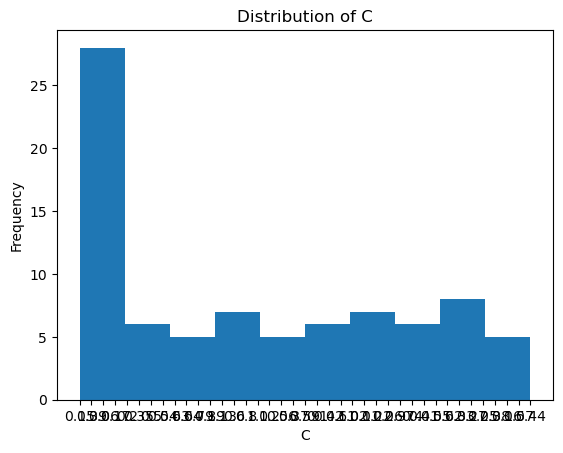

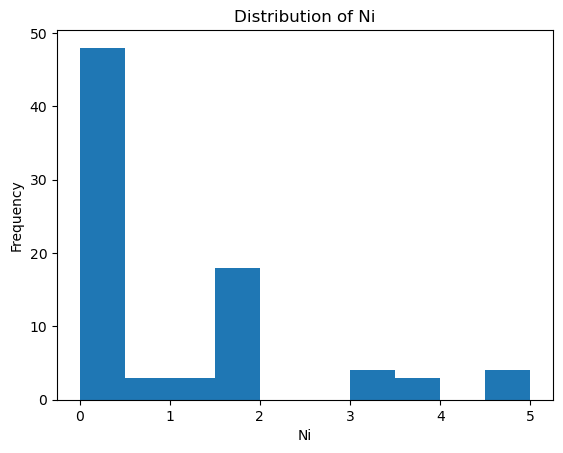

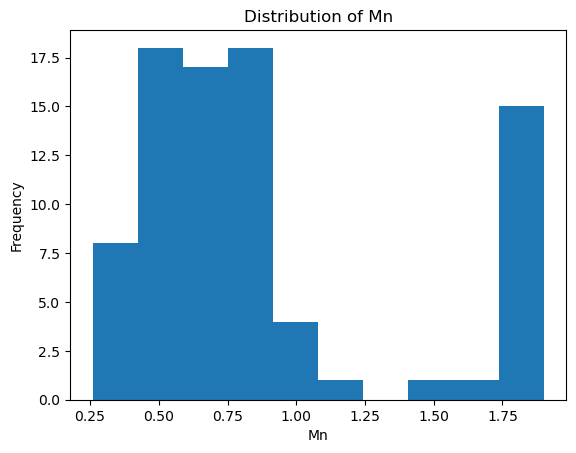

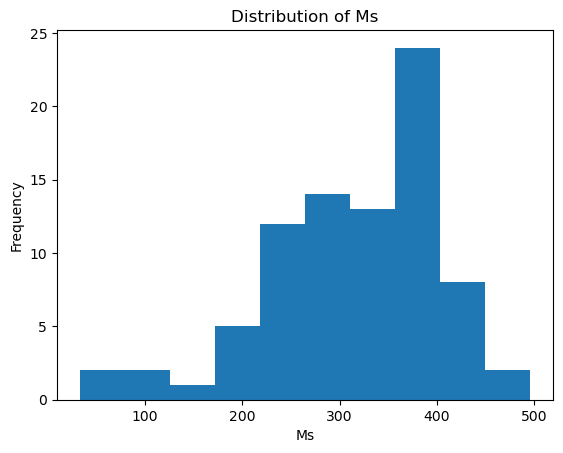

In [40]:
cols = ['C', 'Ni', 'Mn', 'Ms']

for col in cols:
    plt.figure()
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

In [5]:
dff = df[['C','Mn','Ni','Ms']]

In [6]:
dff.head(10)

,C,Mn,Ni,Ms
0,0.15,1.9,0.0,361.0
1,0.15,1.9,0.0,364.0
2,0.15,1.9,0.0,369.0
3,0.15,1.9,0.0,362.0
4,0.15,1.9,0.0,366.0
5,0.15,1.9,0.0,368.0
6,0.15,1.9,0.0,380.0
7,0.15,1.9,0.0,379.0
8,0.15,1.9,0.0,372.0
9,0.15,1.9,0.0,375.0


In [7]:
X = df[['C', 'Ni', 'Mn']]  
y = df['Ms']     

In [8]:
X.sample(5)

,C,Ni,Mn
72,0.62,1.79,0.54
6,0.15,0.00,1.90
15,0.39,1.60,0.65
48,0.22,0.00,0.54
44,0.61,0.00,0.94


In [9]:
y.sample(5)

39    432.00000
60    351.00000
24    320.00000
11    330.06686
63    377.00000
Name: Ms, dtype: float64

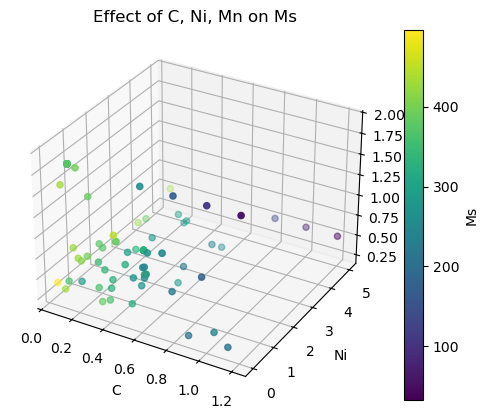

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(df['C'], df['Ni'], df['Mn'], c=df['Ms'])

ax.set_xlabel('C')
ax.set_ylabel('Ni')
ax.set_zlabel('Mn')

plt.title("Effect of C, Ni, Mn on Ms")
plt.colorbar(sc, label='Ms')

plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
model = LinearRegression()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.857542549185452
MSE: 1292.0779679774148


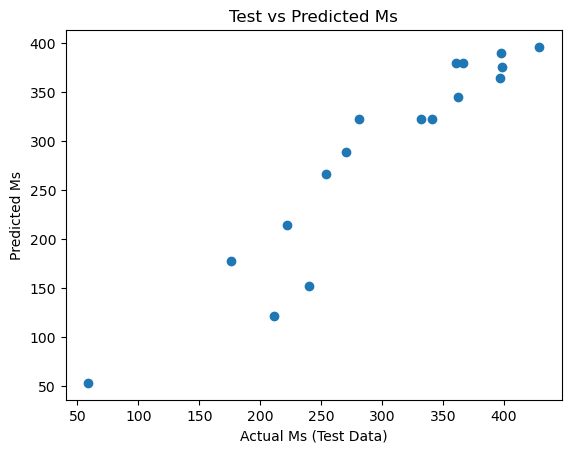

In [16]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ms (Test Data)")
plt.ylabel("Predicted Ms")
plt.title("Test vs Predicted Ms")
plt.show()

In [17]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 482.4306563456873
Coefficients: [-311.23712775  -11.85148119  -29.4614095 ]


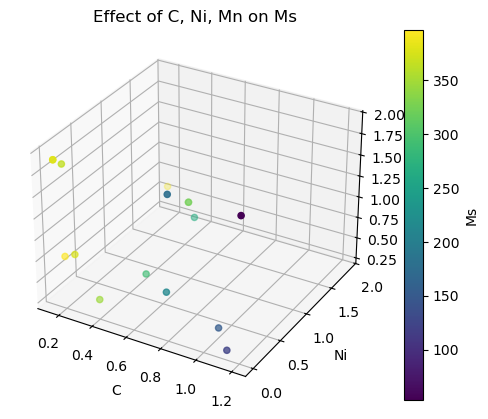

In [18]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(X_test['C'], X_test['Ni'], X_test['Mn'], c=y_pred.flatten())

ax.set_xlabel('C')
ax.set_ylabel('Ni')
ax.set_zlabel('Mn')

plt.title("Effect of C, Ni, Mn on Ms")
plt.colorbar(sc, label='Ms')

plt.show()

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
df = pd.read_csv("combined.csv")

X = df[['C', 'Ni', 'Mn']].values
y = df['Ms'].values.reshape(-1, 1)


In [21]:
df.dropna(inplace=True)

In [22]:
X = df[['C', 'Ni', 'Mn']].values
y = df['Ms'].values.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias
X = np.c_[np.ones((X.shape[0], 1)), X]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [25]:
def gradient_descent(X, y, lr, epochs, batch_size):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for epoch in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            predictions = X_batch @ theta
            error = predictions - y_batch

            gradients = (2/len(X_batch)) * X_batch.T @ error
            theta -= lr * gradients

        loss = np.mean((X @ theta - y) ** 2)
        losses.append(loss)

    return theta, losses


In [26]:
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [8, 16, 32]
epochs_list = [50, 100]

results = []



In [27]:
for lr in learning_rates:
    for batch in batch_sizes:
        for ep in epochs_list:
            
            theta, losses = gradient_descent(X_train, y_train, lr, ep, batch)
            
            y_pred = X_test @ theta
            
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            results.append({
                "learning_rate": lr,
                "batch_size": batch,
                "epochs": ep,
                "R2": r2,
                "MSE": mse
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

    learning_rate  batch_size  epochs        R2           MSE
0           0.001           8      50 -1.013487  18262.168529
1           0.001           8     100  0.467877   4826.312091
2           0.001          16      50 -3.100335  37189.720430
3           0.001          16     100 -0.661882  15073.143116
4           0.001          32      50 -4.954494  54006.793413
5           0.001          32     100 -2.337451  30270.424546
6           0.010           8      50  0.859220   1276.865343
7           0.010           8     100  0.860389   1266.260532
8           0.010          16      50  0.846921   1388.414928
9           0.010          16     100  0.860629   1264.088594
10          0.010          32      50  0.772843   2060.298565
11          0.010          32     100  0.853044   1332.878245
12          0.100           8      50  0.869246   1185.927269
13          0.100           8     100  0.869246   1185.927269
14          0.100          16      50  0.868281   1194.682152
15      

In [28]:
best_model = results_df.sort_values(by="R2", ascending=False).iloc[0]
print("Best Model:\n", best_model)

Best Model:
 learning_rate       0.100000
batch_size          8.000000
epochs             50.000000
R2                  0.869246
MSE              1185.927269
Name: 12, dtype: float64


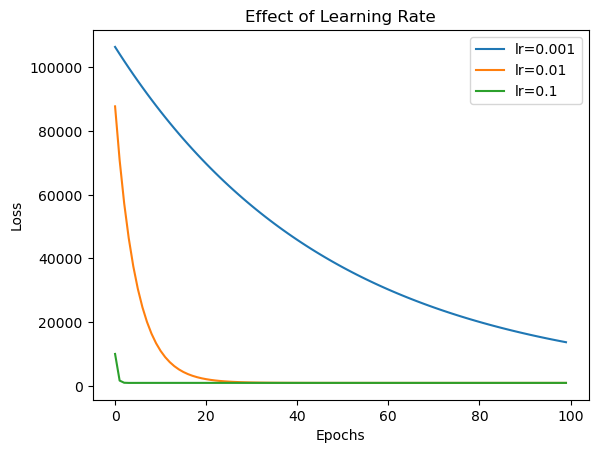

In [29]:
plt.figure()

for lr in learning_rates:
    theta, losses = gradient_descent(X_train, y_train, lr, 100, 16)
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

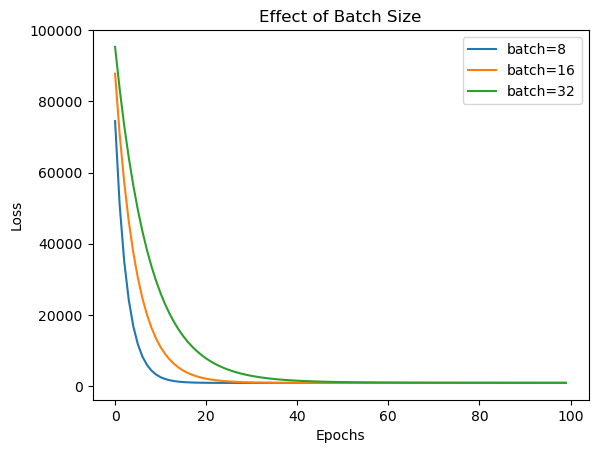

In [30]:
plt.figure()

for batch in batch_sizes:
    theta, losses = gradient_descent(X_train, y_train, 0.01, 100, batch)
    plt.plot(losses, label=f"batch={batch}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Batch Size")
plt.legend()
plt.show()

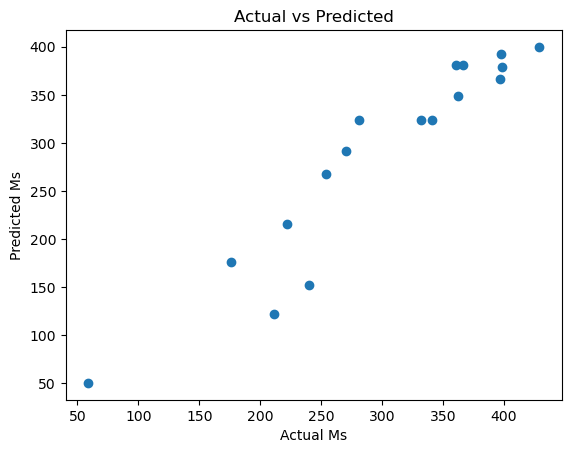

In [31]:
# Train best model again
theta, _ = gradient_descent(X_train, y_train, 0.01, 100, 16)

y_pred = X_test @ theta

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ms")
plt.ylabel("Predicted Ms")
plt.title("Actual vs Predicted")
plt.show()

In [32]:
print(results_df.sort_values(by="R2", ascending=False))

    learning_rate  batch_size  epochs        R2           MSE
12          0.100           8      50  0.869246   1185.927269
13          0.100           8     100  0.869246   1185.927269
15          0.100          16     100  0.868281   1194.682152
14          0.100          16      50  0.868281   1194.682152
16          0.100          32      50  0.865786   1217.310102
17          0.100          32     100  0.865786   1217.310479
9           0.010          16     100  0.860629   1264.088594
7           0.010           8     100  0.860389   1266.260532
6           0.010           8      50  0.859220   1276.865343
11          0.010          32     100  0.853044   1332.878245
8           0.010          16      50  0.846921   1388.414928
10          0.010          32      50  0.772843   2060.298565
1           0.001           8     100  0.467877   4826.312091
3           0.001          16     100 -0.661882  15073.143116
0           0.001           8      50 -1.013487  18262.168529
5       

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 25.18138564775394


In [34]:
from sklearn.metrics import r2_score

# Predictions
y_train_pred = X_train @ theta
y_test_pred = X_test @ theta

# R2 scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("R2 Score (Train):", r2_train)
print("R2 Score (Test):", r2_test)

R2 Score (Train): 0.8788548944810191
R2 Score (Test): 0.8606285044933938


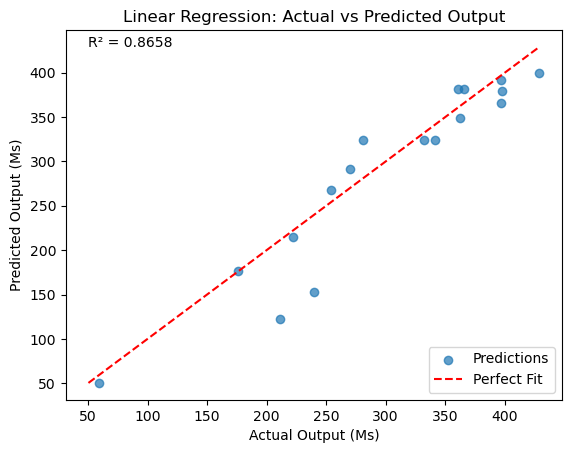

In [35]:
plt.figure()

plt.scatter(y_test, y_pred, alpha=0.7, label="Predictions")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Fit")

plt.xlabel("Actual Output (Ms)")
plt.ylabel("Predicted Output (Ms)")
plt.title("Linear Regression: Actual vs Predicted Output")

plt.text(min_val, max_val, f"R² = {r2:.4f}")

plt.legend()

plt.show()